In [1]:
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib as mpl

import numpy as np

import scienceplots

plt.style.use(['science','ieee'])

#mpl.rcParams['text.usetex'] = False

In [2]:
df = pd.read_csv('low_speed_data_v2x_rtk2.csv')

print(df.columns)


distance = df['distance'].to_numpy()
v_imu = df['velocity_imu'].to_numpy()
v_cam = df['velocity_cam'].to_numpy()
rtk = df['rtk'].to_numpy()

t = df['timestamp_gnss'].to_numpy()

t = t - t[0]

Index(['timestamp_gnss', 'timestamp_cam', 'distance', 'velocity_imu',
       'velocity_cam', 'rtk', 'lat_gnss', 'long_gnss', 'lat_cam', 'long_cam'],
      dtype='object')


In [3]:
distance_rtk = []
distance_nrtk = []

for i in range(len(distance)):
    if (rtk[i] > 0):
        distance_rtk.append(distance[i])
    else:
        distance_nrtk.append(distance[i])
        


distance_mean = np.mean(distance)

distance_std = np.std(distance)

distance_var = np.var(distance)

distance_mean_rtk = np.mean(distance_rtk)

distance_std_rtk = np.std(distance_rtk)

distance_var_rtk = np.var(distance_rtk)

distance_mean_nrtk = np.mean(distance_nrtk)

distance_std_nrtk = np.std(distance_nrtk)

distance_var_nrtk = np.var(distance_nrtk)


print("distance_mean: "+str(distance_mean))
print("distance_std: "+str(distance_std))
print("distance_var: "+str(distance_var))

print("--")

print("distance_mean_rtk: "+str(distance_mean_rtk))
print("distance_std_rtk: "+str(distance_std_rtk))
print("distance_var_rtk: "+str(distance_var_rtk))

print("--")

print("distance_mean_nrtk: "+str(distance_mean_nrtk))
print("distance_std_nrtk: "+str(distance_std_nrtk))
print("distance_var_nrtk: "+str(distance_var_nrtk))

distance_mean: 2.833710081771098
distance_std: 2.3565390227490246
distance_var: 5.553276165738929
--
distance_mean_rtk: 5.304213912149324
distance_std_rtk: 0.7287024983218876
distance_var_rtk: 0.5310073310605605
--
distance_mean_nrtk: 0.7234880599896957
distance_std_nrtk: 0.4204547851902846
distance_var_nrtk: 0.17678222638940838


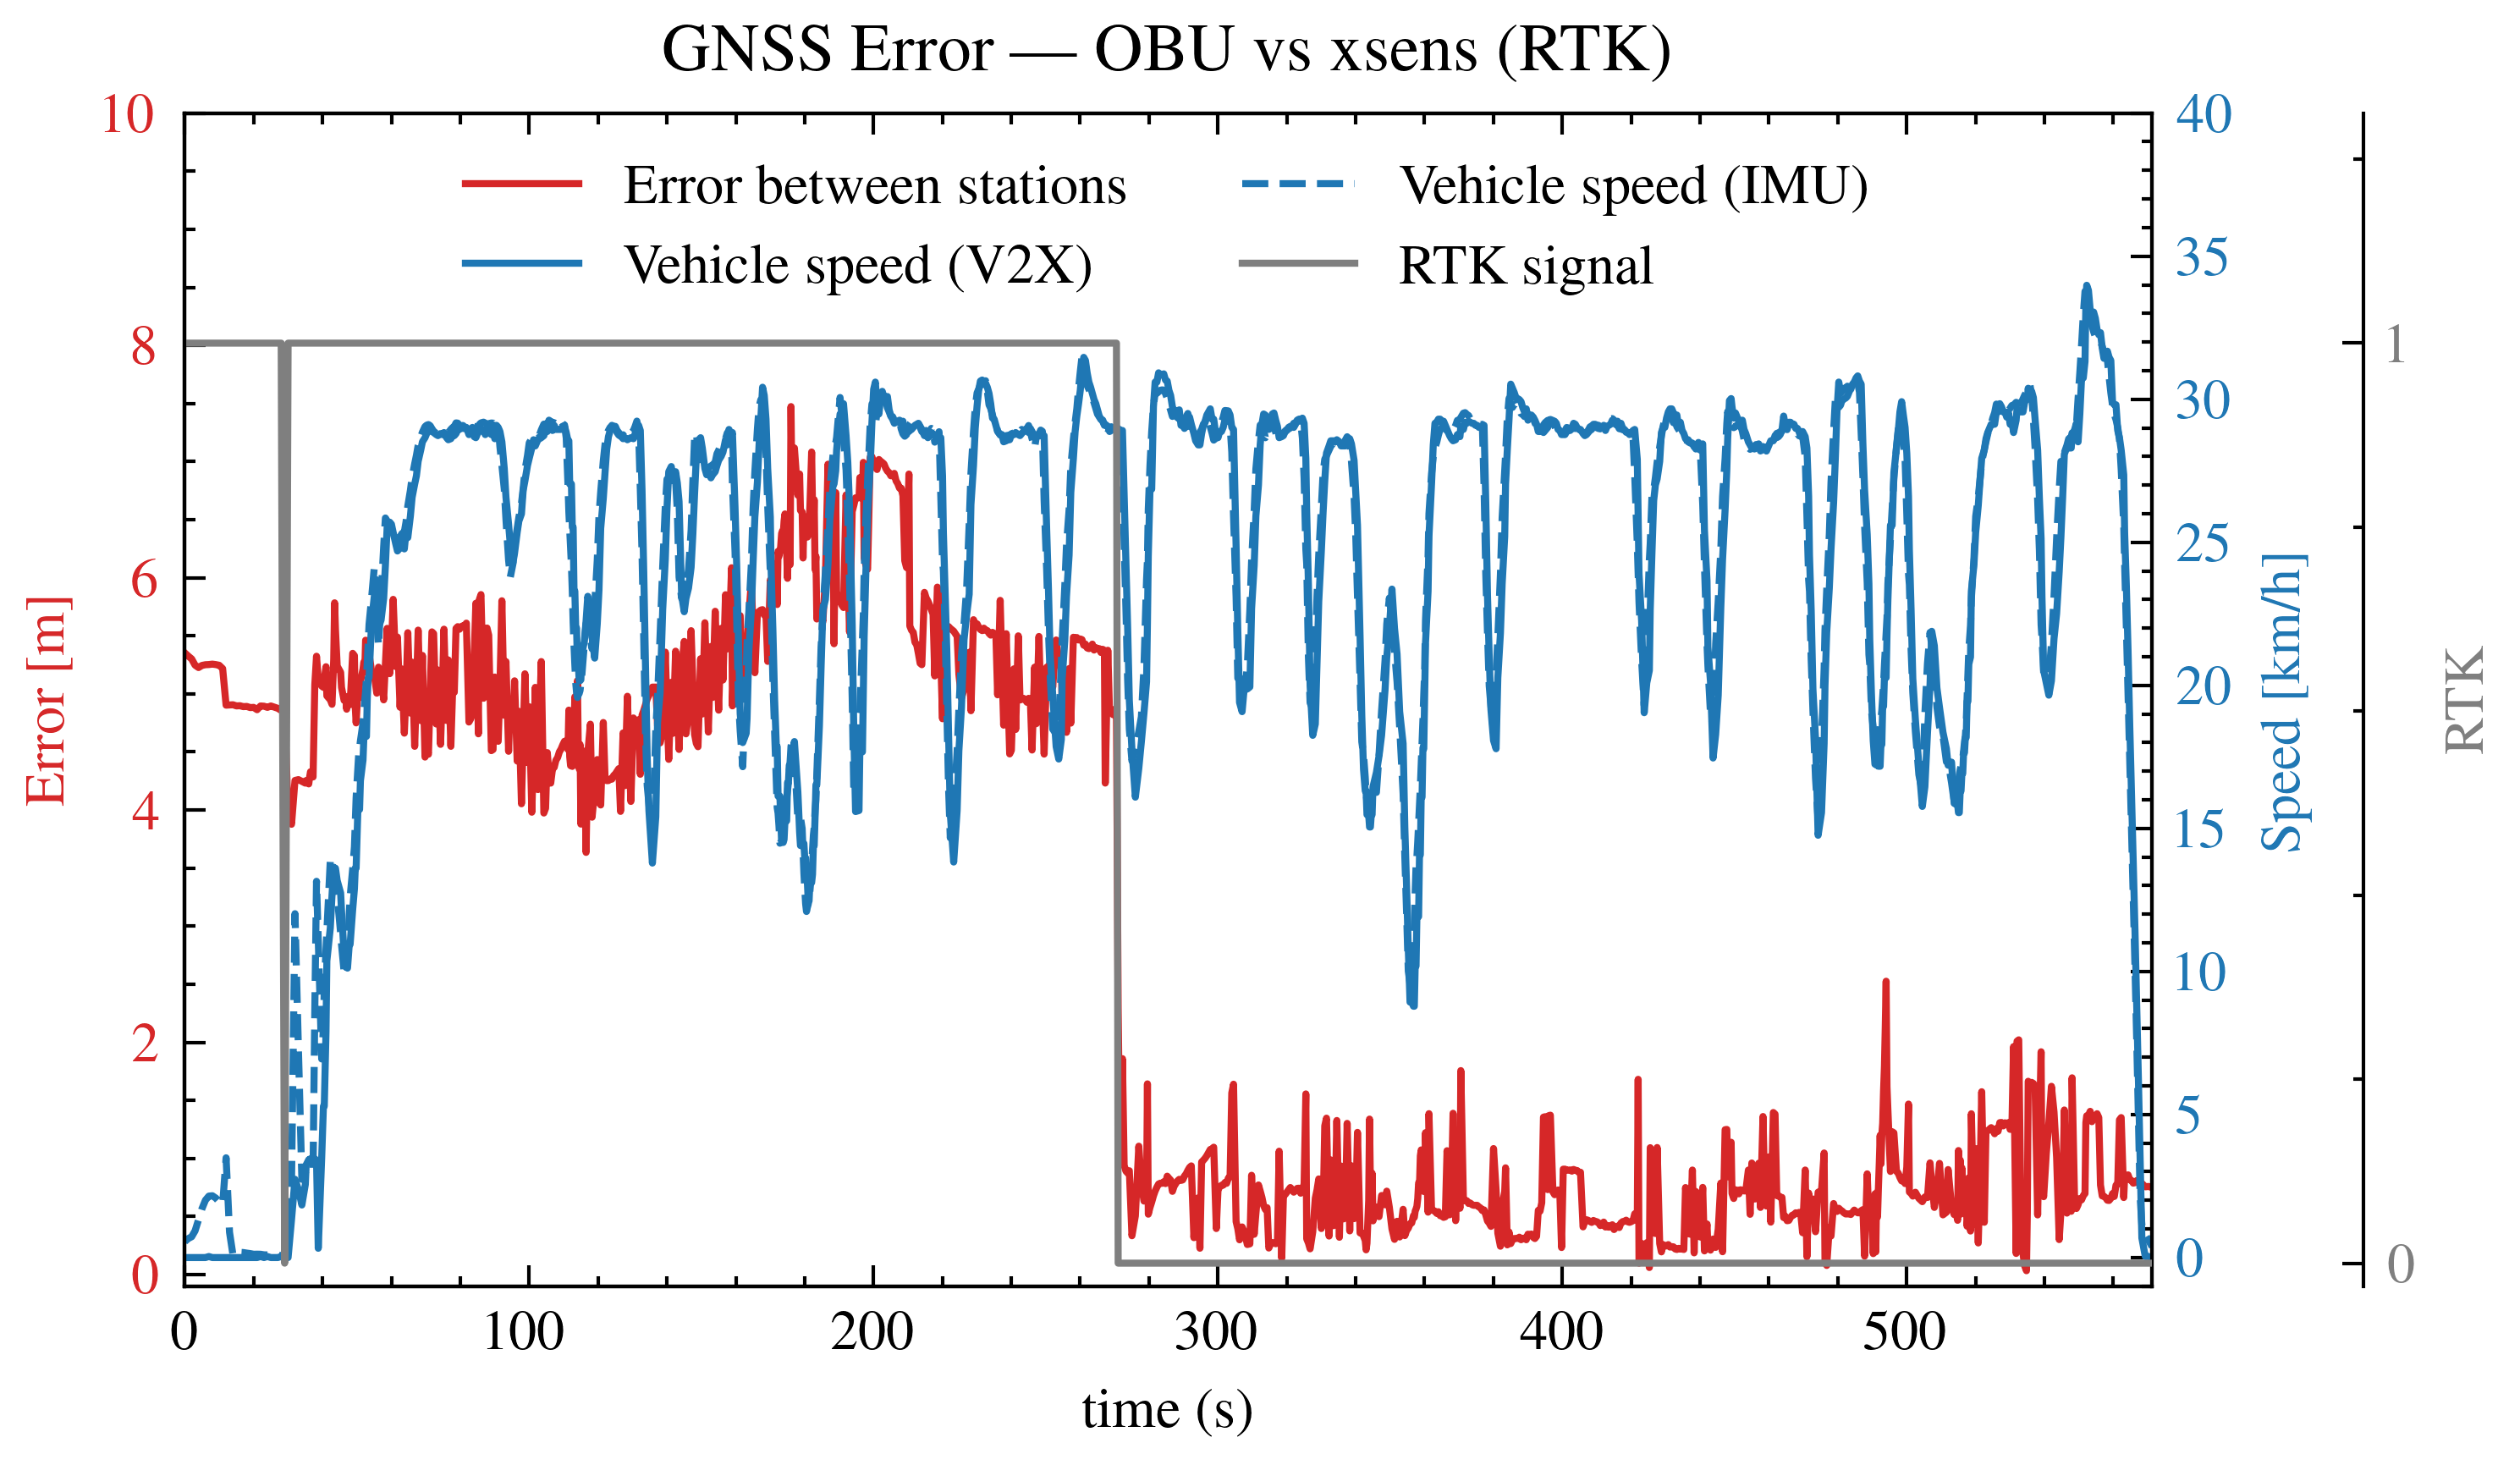

In [4]:
fig, ax1 = plt.subplots(figsize=(5, 3))

plt.title("GNSS Error | OBU vs xsens (RTK)")

color = 'tab:red'
ax1.set_xlabel('time (s)')
ax1.set_ylabel('Error [m]', color=color)
l1, = ax1.plot(t, distance, color=color, label="Error between stations")
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xlim(t[0],t[len(t)-1])
ax1.set_ylim(-0.1, 10)



ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis


color = 'tab:blue'
ax2.set_ylabel('Speed [km/h]', color=color)  # we already handled the x-label with ax1
l2, = ax2.plot(t, v_cam, color=color,  label="Vehicle speed (V2X)")
l3, = ax2.plot(t, v_imu, color=color,  label="Vehicle speed (IMU)", linestyle='--')
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylim(-1, 40)


ax3 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis
ax3.spines['right'].set_position(('outward', 30)) # Adjust '60' as needed for spacing
color = 'tab:gray'
ax3.set_ylabel('RTK', color=color)  # we already handled the x-label with ax1
l4, = ax3.plot(t, rtk, color=color, label="RTK signal")
ax3.tick_params(axis='y', labelcolor=color)
ax3.set_yticks([0, 1])
ax3.set_ylim(-0.025, 1.25)

lines = [l1, l2, l3, l4]
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc='upper center', ncol=2)

#fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.savefig("gnss_behavior.png")
# plt.savefig('gnss_behavior.pdf', format='pdf')

plt.show()

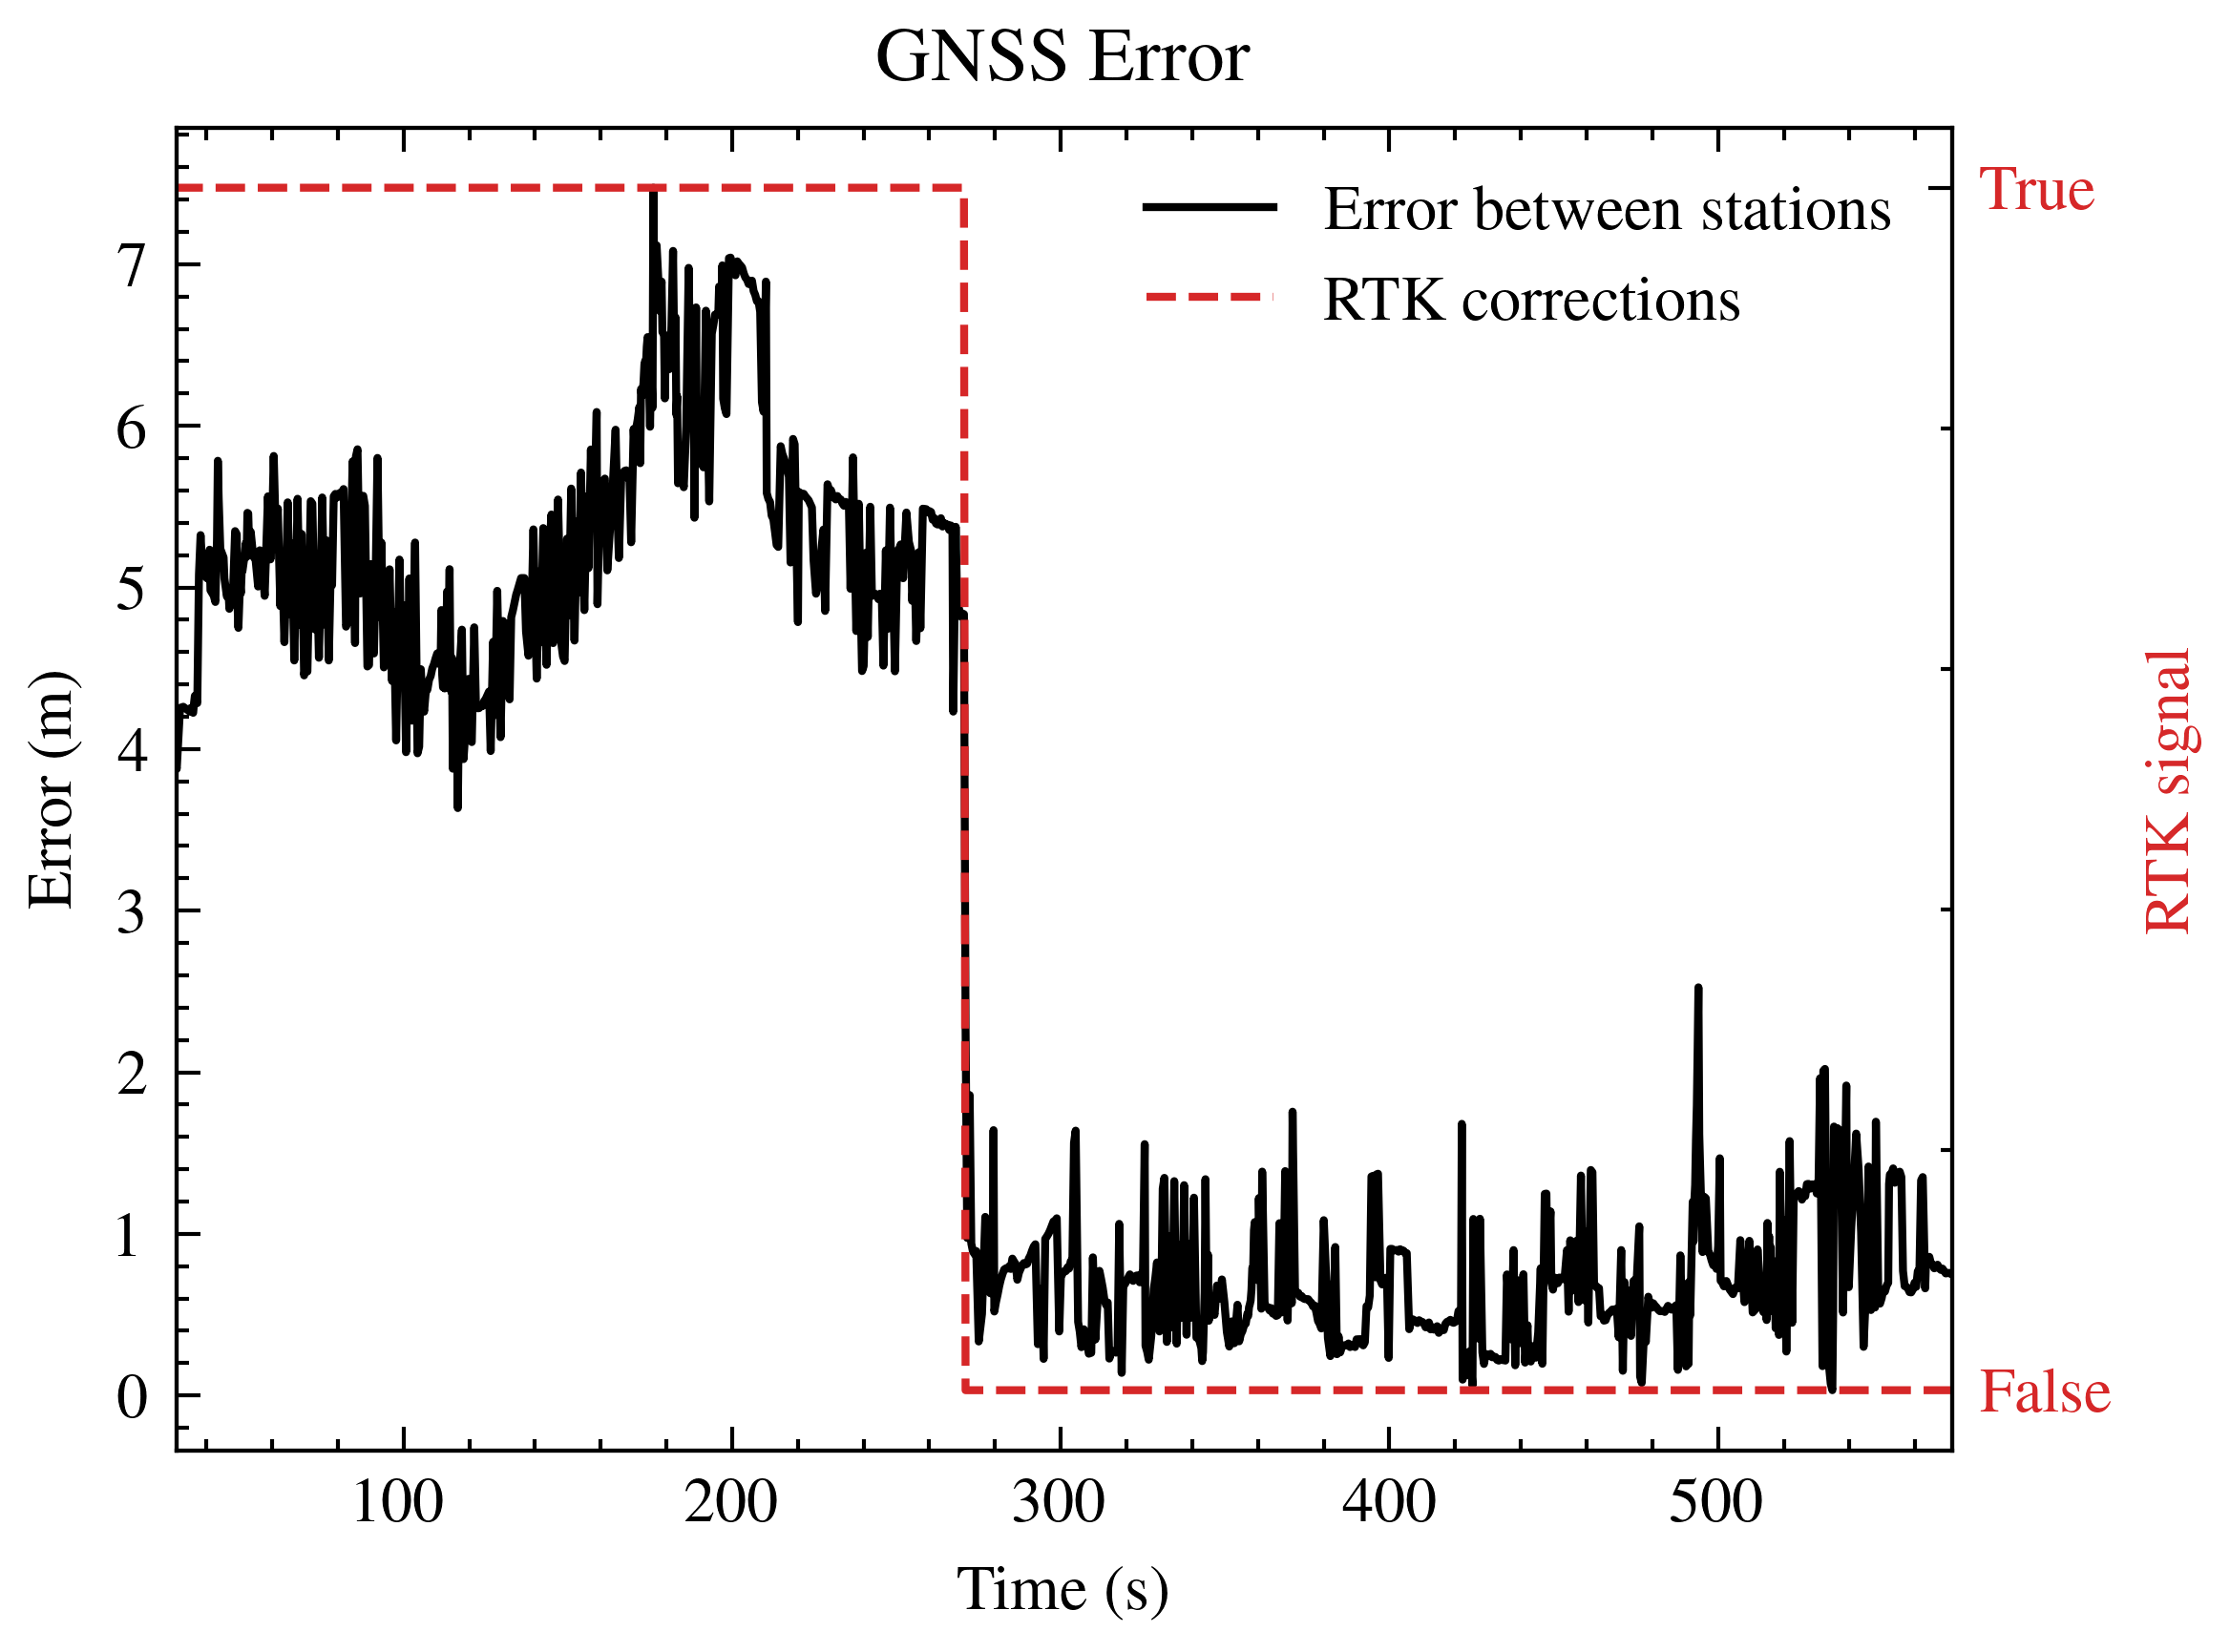

In [5]:
fig, ax1 = plt.subplots(figsize=(4, 3))

plt.title("GNSS Error")

color = 'black'
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Error (m)')
l1, = ax1.plot(t, distance, color=color, label="Error between stations")
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xlim(31,t[len(t)-1])

ax3 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis
color = 'tab:red'
ax3.set_ylabel('RTK signal', color=color)  # we already handled the x-label with ax1
l2, = ax3.plot(t, rtk, color=color, label="RTK corrections", linestyle='--')
ax3.tick_params(axis='y', labelcolor=color)
ax3.set_yticks([0, 1])
ax3.set_yticklabels(['False', 'True'])

lines = [l1, l2]
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc='upper right')
#fig.tight_layout()  # otherwise the right y-label is slightly clipped
#plt.savefig("gnss_error.png")
plt.savefig('gnss_error.pdf', format='pdf')


# High speed

In [6]:
df = pd.read_csv('high_speed_data_v2x_rtk.csv')

print(df.columns)


distance = df['distance'].to_numpy()
v_imu = df['velocity_imu'].to_numpy()
v_cam = df['velocity_cam'].to_numpy()
rtk = df['rtk'].to_numpy()

t = df['timestamp_gnss'].to_numpy()

t = t - t[0]

Index(['timestamp_gnss', 'timestamp_cam', 'distance', 'velocity_imu',
       'velocity_cam', 'rtk', 'lat_gnss', 'long_gnss', 'lat_cam', 'long_cam'],
      dtype='object')


In [7]:
distance_rtk = []
distance_nrtk = []

for i in range(len(distance)):
    if (rtk[i] > 0):
        distance_rtk.append(distance[i])
    else:
        distance_nrtk.append(distance[i])
        


distance_mean = np.mean(distance)

distance_std = np.std(distance)

distance_var = np.var(distance)

distance_mean_rtk = np.mean(distance_rtk)

distance_std_rtk = np.std(distance_rtk)

distance_var_rtk = np.var(distance_rtk)

distance_mean_nrtk = np.mean(distance_nrtk)

distance_std_nrtk = np.std(distance_nrtk)

distance_var_nrtk = np.var(distance_nrtk)


print("distance_mean: "+str(distance_mean))
print("distance_std: "+str(distance_std))
print("distance_var: "+str(distance_var))

print("--")

print("distance_mean_rtk: "+str(distance_mean_rtk))
print("distance_std_rtk: "+str(distance_std_rtk))
print("distance_var_rtk: "+str(distance_var_rtk))

print("--")

print("distance_mean_nrtk: "+str(distance_mean_nrtk))
print("distance_std_nrtk: "+str(distance_std_nrtk))
print("distance_var_nrtk: "+str(distance_var_nrtk))

distance_mean: 2.759931315116439
distance_std: 1.7757933597009405
distance_var: 3.1534420563579544
--
distance_mean_rtk: nan
distance_std_rtk: nan
distance_var_rtk: nan
--
distance_mean_nrtk: 2.759931315116439
distance_std_nrtk: 1.7757933597009405
distance_var_nrtk: 3.1534420563579544


/home/toffanetto/miniconda3/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/toffanetto/miniconda3/lib/python3.12/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/toffanetto/miniconda3/lib/python3.12/site-packages/numpy/_core/_methods.py:222: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/toffanetto/miniconda3/lib/python3.12/site-packages/numpy/_core/_methods.py:180: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/home/toffanetto/miniconda3/lib/python3.12/site-packages/numpy/_core/_methods.py:214: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/toffanetto/miniconda3/lib/python3.12/site-packages/numpy/_core/f

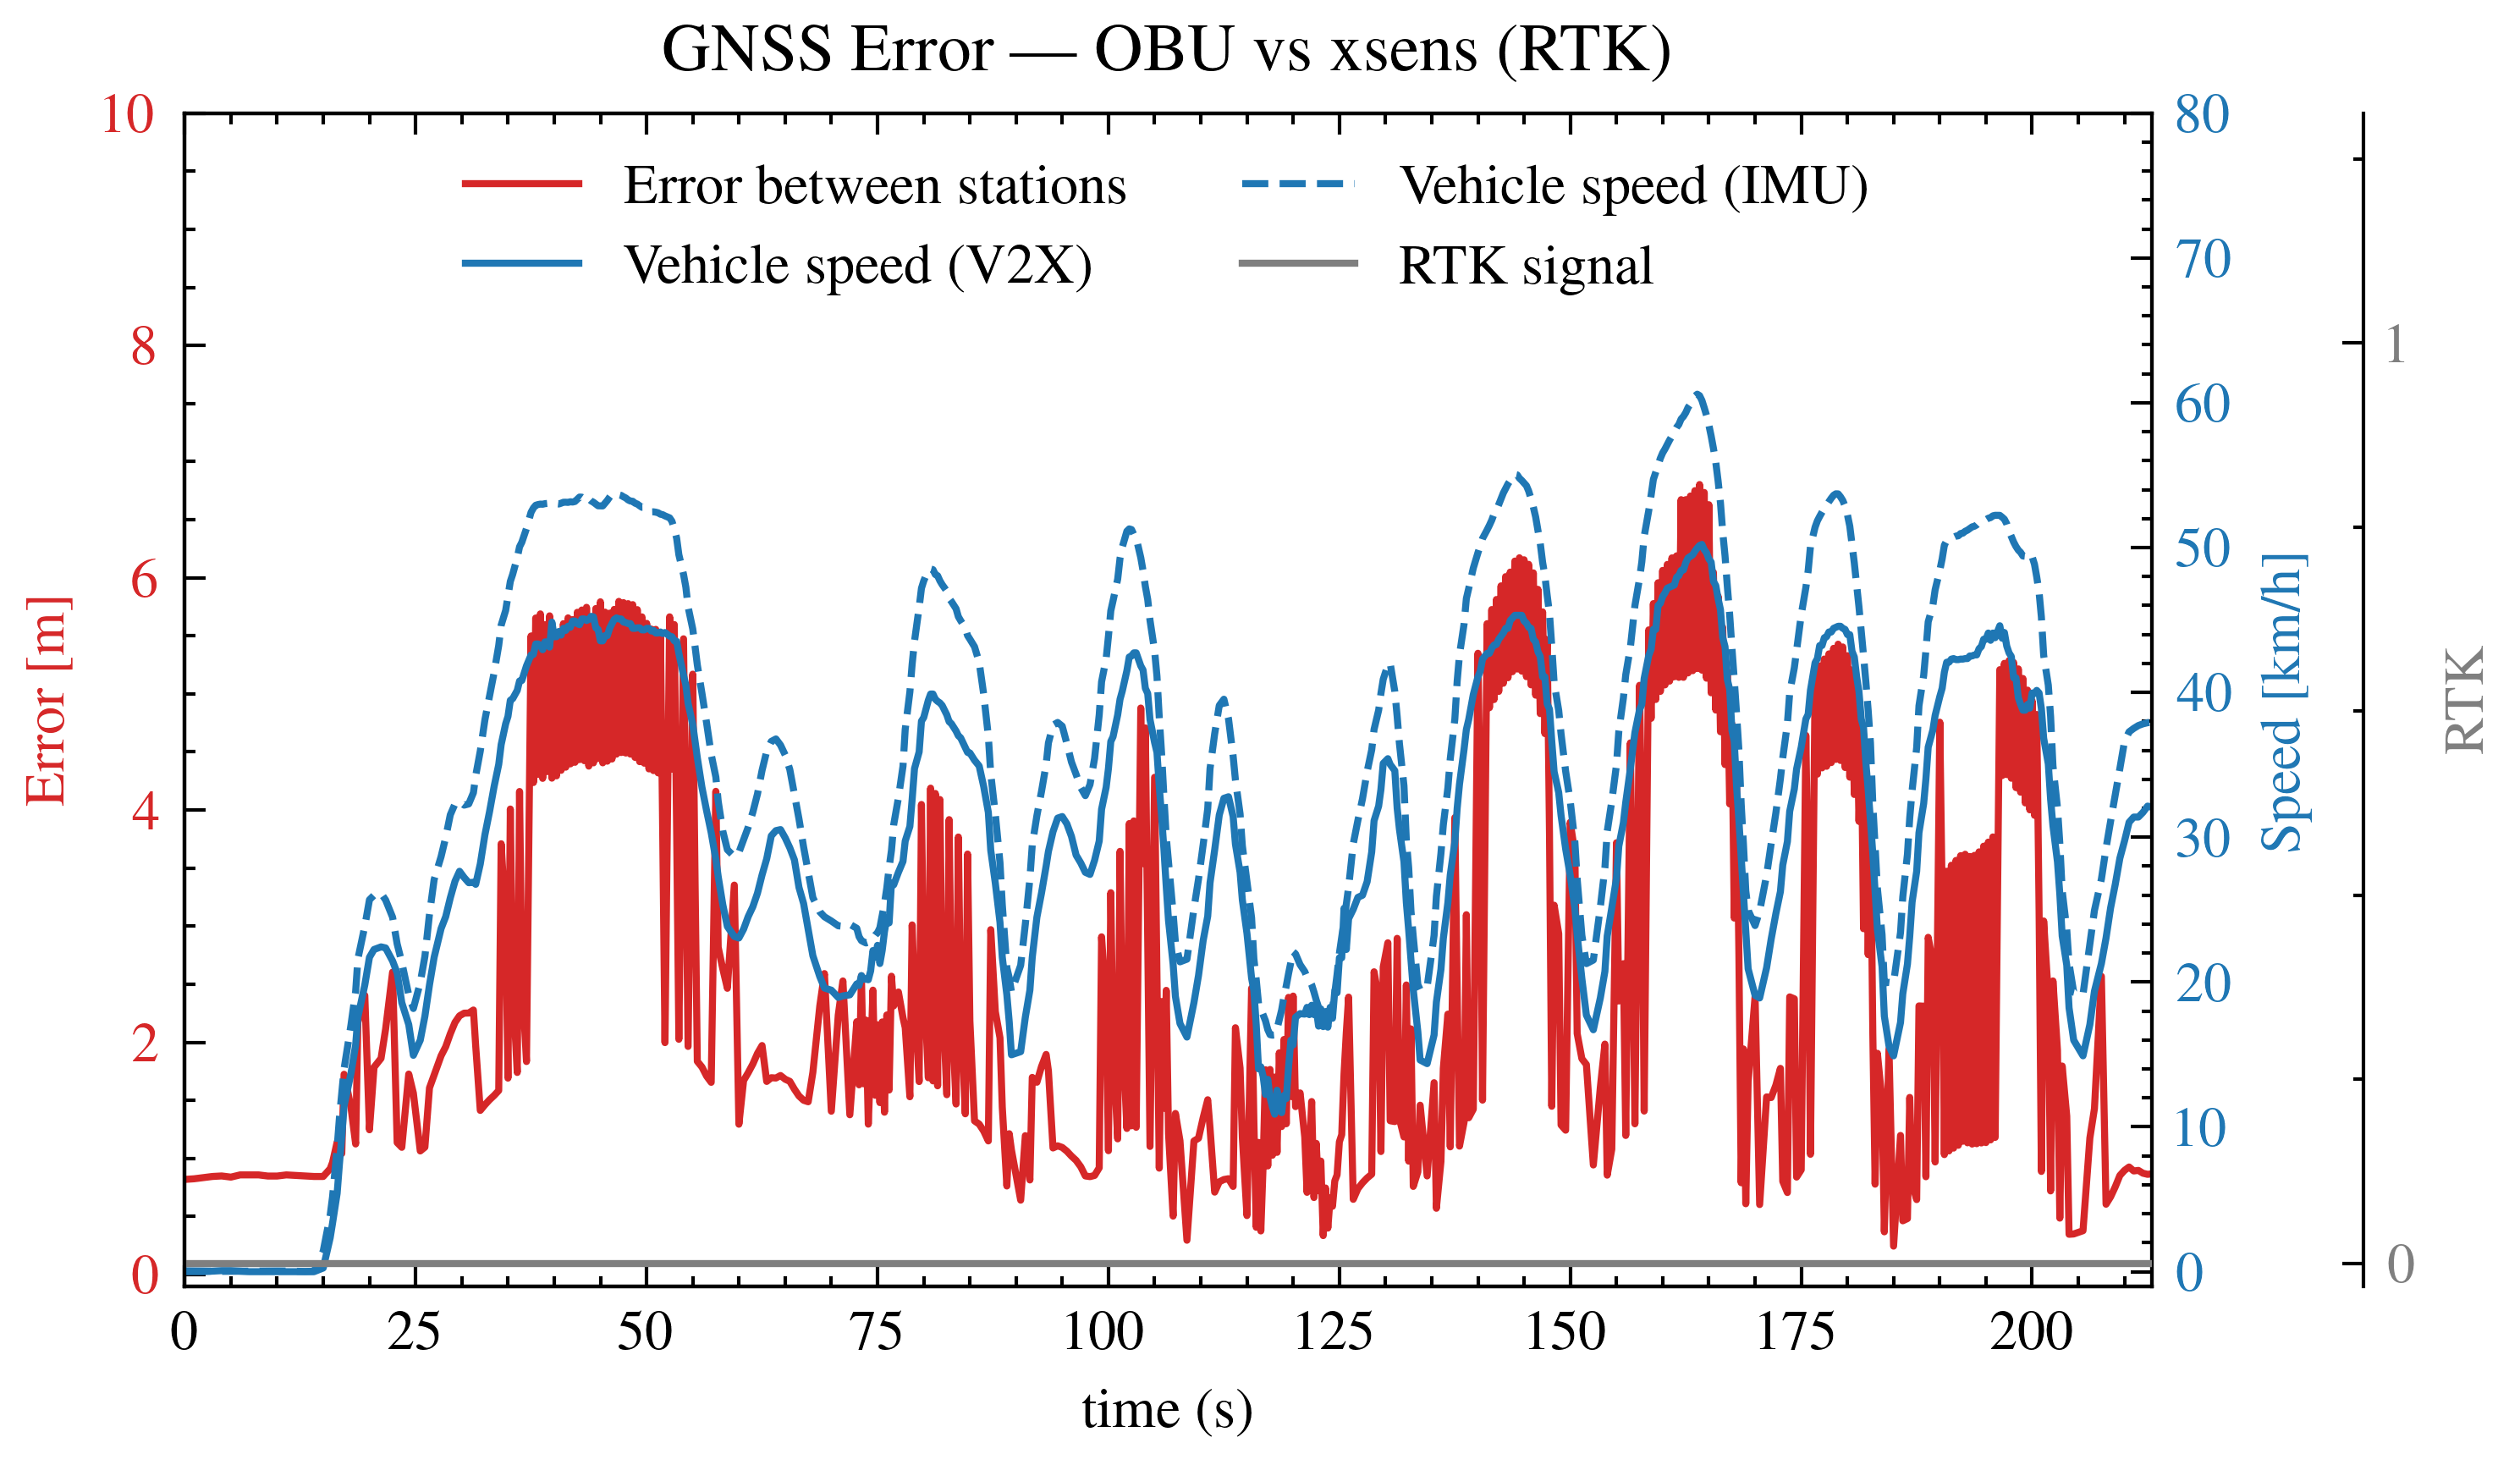

In [9]:
fig, ax1 = plt.subplots(figsize=(5, 3))

plt.title("GNSS Error | OBU vs xsens (RTK)")

color = 'tab:red'
ax1.set_xlabel('time (s)')
ax1.set_ylabel('Error [m]', color=color)
l1, = ax1.plot(t, distance, color=color, label="Error between stations")
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xlim(t[0],t[len(t)-1])
ax1.set_ylim(-0.1, 10)



ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis


color = 'tab:blue'
ax2.set_ylabel('Speed [km/h]', color=color)  # we already handled the x-label with ax1
l2, = ax2.plot(t, v_cam, color=color,  label="Vehicle speed (V2X)")
l3, = ax2.plot(t, v_imu, color=color,  label="Vehicle speed (IMU)", linestyle='--')
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylim(-1, 80)


ax3 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis
ax3.spines['right'].set_position(('outward', 30)) # Adjust '60' as needed for spacing
color = 'tab:gray'
ax3.set_ylabel('RTK', color=color)  # we already handled the x-label with ax1
l4, = ax3.plot(t, rtk, color=color, label="RTK signal")
ax3.tick_params(axis='y', labelcolor=color)
ax3.set_yticks([0, 1])
ax3.set_ylim(-0.025, 1.25)

lines = [l1, l2, l3, l4]
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc='upper center', ncol=2)

#fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.savefig("high_gnss_behavior.png")
# plt.savefig('gnss_behavior.pdf', format='pdf')

plt.show()